# CNN-Based Malaria Parasite Recognition in Human Blood Smear Images


## Project Rules Checklist

#TODO
- Use 3 different datasets from 3 different sources.
- Only 1 dataset can be binary (2 classes).
- The other 2 datasets must have at least 3 classes.
- Keep each dataset under 50K images.
- Train 9 models from scratch (3 models x 3 datasets).
- Train 2 extra models with transfer learning.
- Tune at least 1 hyperparameter (learning rate, batch size, or loss).
- Compare with accuracy, precision, recall, F1, and plots.
- Prepare Grad-CAM or TSNE for at least 4 models.

#HINTS
- Keep all base hyperparameters the same for fair comparison.
- Save all runs using one naming format.

## Task Split (5 Members)

### Member 1 — Data Owner
#TODO
- Download all datasets.
- Do class mapping/filtering.
- Keep final datasets under 50K images.
- Create train/val/test split files.

#HINTS
- Save split summary table: dataset, classes, image count, split ratios.

### Member 2 — Pipeline Owner
#TODO
- Build data pipeline plan (loading, preprocessing, augmentation).
- Define common input size and normalization policy.
- Write data quality checks list (missing images, broken labels).

#HINTS
- Keep one transform policy for all 9 baseline runs.

### Member 3 — ResNet Track Owner
#TODO
- Run ResNet-18 on dataset A, B, C (from scratch).
- Track failures and rerun failed jobs.

#HINTS
- Save best checkpoint and final metrics for each run.

### Member 4 — VGG/MobileNet Track + Optimization Owner
#TODO
- Run VGG-16 on dataset A, B, C (from scratch).
- Run MobileNet-V2 on dataset A, B, C (from scratch).
- Run 1 optimization study on one baseline model.

#HINTS
- Use a small optimization grid to save time.

### Member 5 — Evaluation & Visuals Owner
#TODO
- Prepare metric comparison sheets.
- Prepare plots and confusion matrix list.
- Prepare Grad-CAM or TSNE plan for at least 4 models.
- Keep clean notes for report writing team.

#HINTS
- Use one shared template for model result summaries.

## What Can Run in Parallel vs Not

### Can run in parallel
- Member 2 can define pipeline rules while Member 1 downloads data.
- Member 3 and Member 4 can prepare training templates before full dataset is ready.
- Member 5 can prepare result tables and plotting templates early.

### Cannot run in parallel (depends on previous step)
- Final training runs need final train/val/test split from Member 1.
- Fair model comparison needs common preprocessing rules from Member 2.
- Final comparison plots need completed model outputs from Members 3 and 4.
- Final progress report needs initial results from all tracks.

## 6-Day Plan (Simple)

### Day 1
#TODO
- M1: download datasets and verify source links.
- M2: freeze preprocessing rules (resize, normalize, augmentation).
- M3/M4: prepare model run checklist and run naming format.
- M5: create metric and plot templates.

### Day 2
#TODO
- M1: complete class mapping/filtering and split definitions.
- M2: finalize pipeline checks and handoff rules.
- M3/M4: run small smoke tests on one dataset each.
- M5: confirm evaluation format with team.

### Day 3
#TODO
- M3: launch ResNet full runs (3 datasets).
- M4: launch VGG and MobileNet runs (start with easier datasets).
- M5: start collecting first results and build comparison table.

### Day 4
#TODO
- M3/M4: continue training and rerun failed jobs.
- M4: start optimization run (one hyperparameter only).
- M5: generate first metric plots from available runs.

### Day 5
#TODO
- M3/M4: finish all 9 baseline runs and 2 transfer learning runs.
- M5: finish comparison plots and Grad-CAM/TSNE plan for 4 models.
- All: verify missing outputs, fill gaps.

### Day 6
#TODO
- All: lock final result files for report use.
- M5: finalize clean summary package for report team.
- Team lead: final quality check and handoff to report writing in .tex.

## Model Matrix to Complete

#TODO
- Scratch runs (9):
  - ResNet-18 x Dataset A/B/C
  - VGG-16 x Dataset A/B/C
  - MobileNet-V2 x Dataset A/B/C
- Transfer learning runs (2):
  - Choose any 2 dataset+model combinations
- Optimization runs (at least 1 setting change):
  - learning rate OR batch size OR loss function

#HINTS
- Pick transfer learning on harder dataset(s).
- Pick optimization on the model with best baseline potential.

## Result Logging Template (Text Only)

#TODO
For each run, record:
- dataset name
- model name
- run type (scratch / transfer learning / optimization)
- hyperparameters used
- best validation metrics
- test metrics (accuracy, precision, recall, F1)
- checkpoint path
- notes (failed run reason or success notes)

#HINTS
- Keep this format identical for all members.
- This will save time during report writing in the .tex file.

## Quick Quality Checklist Before Handoff

#TODO
- 3 datasets confirmed from different sources.
- Class constraints confirmed (only 1 binary dataset).
- 9 scratch runs completed.
- 2 transfer learning runs completed.
- 1 optimization attempt completed.
- Metrics and plots prepared.
- Grad-CAM or TSNE prepared for at least 4 models.

#HINTS
- Do one final team sync meeting to verify missing items.

---
## Member 2: Pipeline Implementation

**Goal:** Data quality checks, common transform policy, and DataLoader creation for all 3 datasets.  
All 9 baseline training runs (ResNet-18, VGG-16, MobileNet-V2 × miracle9to9, orvile, malaria) consume `dataloaders_registry` directly.


### Step 1 - Imports & Constants


In [1]:
from pathlib import Path
import pandas as pd
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DATA_ROOT        = Path("../data/raw")
IMAGE_INPUT_SIZE = 224
BATCH_SIZE       = 32
NUM_WORKERS      = 0
DATASET_NAMES    = ["miracle9to9", "orvile", "malaria"]
IMAGE_EXTENSIONS = {".jpg", ".png"}

# ImageNet statistics  applies to ResNet-18, VGG-16, and MobileNet-V2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


### Step 2 - Data Quality Checks

Inventory every image under `data/raw/`, flag zero-byte (broken) files, and report class distribution and imbalance ratios per dataset/split.


In [ ]:
all_image_paths = pd.Series([
    path for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
])

image_inventory_df = pd.DataFrame({
    "dataset":   all_image_paths.map(lambda path: path.relative_to(DATA_ROOT).parts[0]),
    "split":     all_image_paths.map(lambda path: path.relative_to(DATA_ROOT).parts[1]),
    "class_raw": all_image_paths.map(lambda path: path.parent.name),
    "file_size": all_image_paths.map(lambda path: path.stat().st_size),
    "filepath":  all_image_paths,
})

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

image_inventory_df["is_valid"] = all_image_paths.map(is_valid_image)

broken_files_df = image_inventory_df[~image_inventory_df["is_valid"]]
print(f"Broken/unreadable files found: {len(broken_files_df)}")
if not broken_files_df.empty:
    with open("broken_files_report.txt", "w") as report_file:
        report_file.write("Broken/unreadable files:\n")
        report_file.write(broken_files_df[["dataset", "split", "class_raw", "filepath"]].to_string(index=False))
        report_file.write("\n")
    print(f"\nBroken files report saved to 'broken_files_report.txt' with {len(broken_files_df)} broken files.\n")

valid_images_inventory_df = image_inventory_df[image_inventory_df["is_valid"]]
valid_images_count = len(valid_images_inventory_df)
print(f"\nTotal valid images: {valid_images_count}") 

class_distribution_df = (
    valid_images_inventory_df
    .groupby(["dataset", "split", "class_raw"])
    .size()
    .reset_index(name="image_count")
)
print("\nClass distribution:")
print(class_distribution_df.to_string(index=False))

split_totals_df = (
    valid_images_inventory_df
    .groupby(["dataset", "split"])
    .size()
    .reset_index(name="total_images")
)
print("\nSplit totals:")
print(split_totals_df.to_string(index=False))

imbalance_df = (
    class_distribution_df
    .groupby(["dataset", "split"])["image_count"]
    .agg(max_count="max", min_count="min")
    .assign(imbalance_ratio=lambda dataframe: (dataframe["max_count"] / dataframe["min_count"]).round(2))
    .reset_index()
)
print("\nClass imbalance ratios (max_class_count / min_class_count):")
print(imbalance_df.to_string(index=False))


Broken/unreadable files found: 1532
dataset split   class_raw                                                                       filepath
malaria  test  gametocyte   ..\data\raw\malaria\test\gametocyte\96957ec3-de17-41cf-855b-1388814e5918.jpg
malaria  test  gametocyte   ..\data\raw\malaria\test\gametocyte\a1265844-329c-4a49-a37f-e0541b83a50c.jpg
malaria  test  gametocyte   ..\data\raw\malaria\test\gametocyte\bdfbad30-fa2f-4285-bf02-6064ab6d869c.jpg
malaria  test        ring         ..\data\raw\malaria\test\ring\0346611b-ea43-45bd-9f16-c6e8086273d2.jpg
malaria  test        ring         ..\data\raw\malaria\test\ring\03be08c8-2cf3-4de6-8ac6-5f7817a6a643.jpg
malaria  test        ring         ..\data\raw\malaria\test\ring\0897f682-5301-49fc-a8d5-9df7762040bb.jpg
malaria  test        ring         ..\data\raw\malaria\test\ring\15a5849d-8bc7-4e01-938b-c1f55067787d.jpg
malaria  test        ring         ..\data\raw\malaria\test\ring\291fe50c-2134-4708-bfa4-09b36ffea123.jpg
malaria  test      

### Step 3 - Transform Policy

One shared policy for all 9 baseline training runs.  
- `training_transforms` : resize → geometric augmentation → color jitter → normalize  
- `evaluation_transforms` : resize → normalize only (no augmentation on val/test)


In [3]:
training_transforms = transforms.Compose([
    transforms.Resize((IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

evaluation_transforms = transforms.Compose([
    transforms.Resize((IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("training_transforms :")
print(training_transforms)
print("\nevaluation_transforms :")
print(evaluation_transforms)


training_transforms :
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

evaluation_transforms :
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### Step 4 - MalariaDataset

Custom `Dataset` that works for all three datasets.  
Accepts a pre-filtered `split_inventory_df` slice from `valid_images_inventory_df` (Step 2), so only validated images are ever loaded.  
Handles `orvile`'s duplicate training folders (`"gametocyte 2"` → `"gametocyte"`) by stripping the trailing numeric suffix via vectorized regex on class folder names.


In [4]:
class MalariaDataset(Dataset):
    def __init__(self, split_inventory_df, transform=None):
        normalized_class_names = split_inventory_df["class_raw"].str.replace(r"\s+\d+$", "", regex=True)

        unique_classes   = sorted(normalized_class_names.unique())
        class_to_index   = {class_name: index for index, class_name in enumerate(unique_classes)}

        self.image_paths  = split_inventory_df["filepath"].to_numpy()
        self.labels       = normalized_class_names.map(class_to_index).to_numpy()
        self.class_names  = unique_classes
        self.class_to_idx = class_to_index
        self.transform    = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(self.labels[index])


### Step 5 - Datasets & DataLoaders

`datasets_registry[dataset_name][split]` → `MalariaDataset`  
`dataloaders_registry[dataset_name][split]` → `DataLoader` ready for training  

All 9 scratch models and 2 transfer learning models consume `dataloaders_registry`.


In [5]:
SPLIT_TRANSFORMS = {"train": training_transforms, "val": evaluation_transforms, "test": evaluation_transforms}

datasets_registry = {
    dataset_name: {
        split: MalariaDataset(
            valid_images_inventory_df[
                (valid_images_inventory_df["dataset"] == dataset_name) &
                (valid_images_inventory_df["split"]   == split)
            ].reset_index(drop=True),
            transform=split_transform,
        )
        for split, split_transform in SPLIT_TRANSFORMS.items()
    }
    for dataset_name in DATASET_NAMES
}

dataloaders_registry = {
    dataset_name: {
        split: DataLoader(
            dataset,
            batch_size  = BATCH_SIZE,
            shuffle     = (split == "train"),
            num_workers = NUM_WORKERS,
            pin_memory  = torch.cuda.is_available(),
            drop_last   = (split == "train"),
        )
        for split, dataset in split_datasets.items()
        if len(dataset) > 0
    }
    for dataset_name, split_datasets in datasets_registry.items()
}

for dataset_name, split_datasets in datasets_registry.items():
    for split_name, dataset in split_datasets.items():
        if len(dataset) == 0:
            print(f"{dataset_name:15s} | {split_name:5s} | SKIPPED since 0 valid images")
            continue
        num_batches = len(dataloaders_registry[dataset_name][split_name])
        print(f"{dataset_name:15s} | {split_name:5s} | {len(dataset):5d} images | {num_batches:3d} batches | classes: {dataset.class_names}")


miracle9to9     | train | 23425 images | 732 batches | classes: ['Parasitized', 'Uninfected']
miracle9to9     | val   |  4133 images | 130 batches | classes: ['Parasitized', 'Uninfected']
miracle9to9     | test  | 15832 images | 495 batches | classes: ['Parasitized', 'Uninfected']
orvile          | train | SKIPPED since 0 valid images
orvile          | val   | SKIPPED since 0 valid images
orvile          | test  | SKIPPED since 0 valid images
malaria         | train | SKIPPED since 0 valid images
malaria         | val   | SKIPPED since 0 valid images
malaria         | test  | SKIPPED since 0 valid images


### Step 6 - Pipeline Verification

Sanity-check one batch per dataset: confirm tensor shape, value range, and label validity.  
Visualize one sample grid per dataset to confirm images look correct.


miracle9to9     | shape: (32, 3, 224, 224) | pixel range: [-2.12, 2.25] | labels: [0, 0, 0, 0]
orvile          | SKIPPED — no valid training images
malaria         | SKIPPED — no valid training images


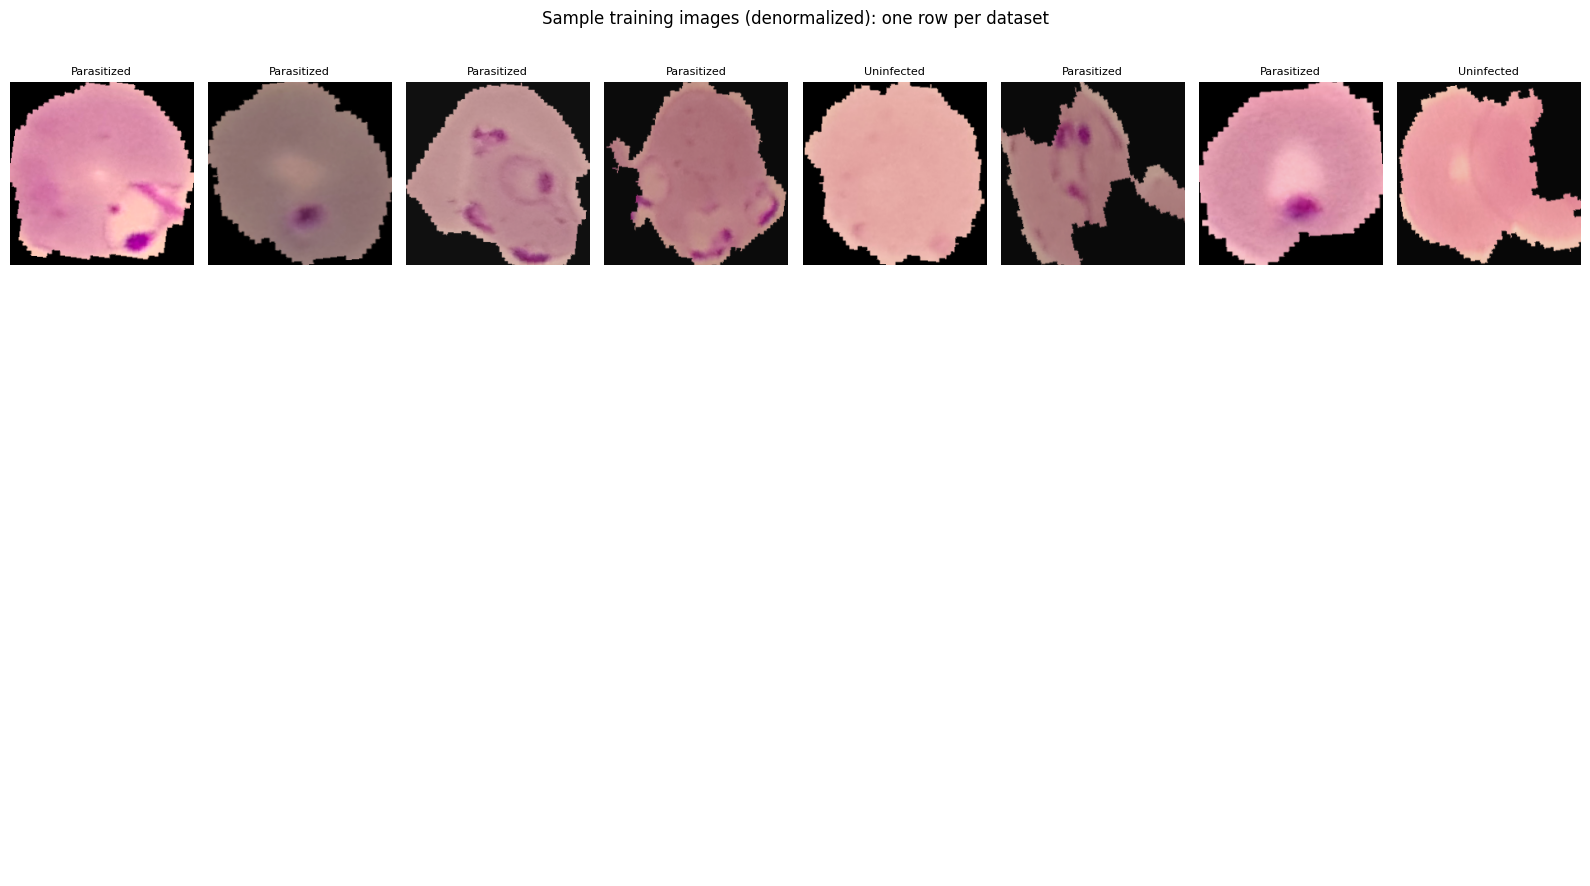


All assertions passed.


In [6]:
import matplotlib.pyplot as plt

def denormalize(tensor_image):
    """Reverse ImageNet normalization for visualization."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor_image * std + mean).clamp(0, 1)

figure, axes = plt.subplots(len(DATASET_NAMES), BATCH_SIZE // 4, figsize=(16, 3 * len(DATASET_NAMES)))

for row_index, dataset_name in enumerate(DATASET_NAMES):
    if "train" not in dataloaders_registry.get(dataset_name, {}):
        print(f"{dataset_name:15s} | SKIPPED — no valid training images")
        for column_index in range(BATCH_SIZE // 4):
            axes[row_index, column_index].axis("off")
        axes[row_index, 0].set_ylabel(dataset_name, fontsize=10, rotation=90, labelpad=10)
        continue

    sample_images, sample_labels = next(iter(dataloaders_registry[dataset_name]["train"]))
    class_names = datasets_registry[dataset_name]["train"].class_names
    num_classes = len(class_names)

    assert sample_images.ndim == 4, f"Expected 4D tensor, got {sample_images.ndim}D"
    assert sample_images.shape[1:] == (3, IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE), f"Unexpected shape: {sample_images.shape}"
    assert sample_labels.min().item() >= 0 and sample_labels.max().item() < num_classes, "Label out of range"
    print(f"{dataset_name:15s} | shape: {tuple(sample_images.shape)} | pixel range: [{sample_images.min():.2f}, {sample_images.max():.2f}] | labels: {sample_labels[:4].tolist()}")

    for column_index in range(BATCH_SIZE // 4):
        display_image = denormalize(sample_images[column_index]).permute(1, 2, 0).numpy()
        label_text    = class_names[sample_labels[column_index].item()]
        axes[row_index, column_index].imshow(display_image)
        axes[row_index, column_index].set_title(label_text, fontsize=8)
        axes[row_index, column_index].axis("off")
    axes[row_index, 0].set_ylabel(dataset_name, fontsize=10, rotation=90, labelpad=10)

plt.suptitle("Sample training images (denormalized): one row per dataset", fontsize=12)
plt.tight_layout()
plt.show()

print("\nAll assertions passed.")
